In [1]:
# 1) Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%matplotlib inline

In [3]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


In [ ]:
!ls

 code					       SOLPEx
'Colab Notebooks'			       SOLPS
'Copy of APP-FPP_APS25_Poster_final.gslides'   SOLPS_DB
 data					       TALKS
 dataset_1d				       test_unet
 Diffusion				       Unet2
 GSM					      'Untitled document (1).gdoc'
 Paperpile				      'Untitled document.gdoc'
 quixote-master				       vol.pdf
 scripts				       west_runs.ipynb
 SOLARIS				       WIP


In [ ]:
![ -d SOLPEx ] || git clone https://github.com/abdoudiaw/SOLPEx.git SOLPEx

In [ ]:
%cd SOLPEx
!git pull origin main

/content/drive/MyDrive/SOLPEx
From https://github.com/abdoudiaw/SOLPEx
 * branch            main       -> FETCH_HEAD


In [ ]:
!pip install -e .

Obtaining file:///content/drive/MyDrive/SOLPEx
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for solpex (pyproject.toml) ... done
  Created wheel for solpex: filename=solpex-0.1.0-0.editable-py3-none-any.whl size=2717 sha256=c5b3ab605bf01559b0c9753a1675c096824a89430a639e90291d9338fd2379c1
  Stored in directory: /tmp/pip-ephem-wheel-cache-9mqo6a8b/wheels/d3/c6/6f/be2ad1d4cb769fd5a7e70b7164329dc7a30f83863ee2d6fbc0
Successfully built solpex


In [ ]:
# \!grep -R --line-number -E "(^|[^.])import solpex|from solpex" /content/drive/MyDrive/SOLPEx/solpex


/content/drive/MyDrive/Unet2/solps_ai/utils.py:3:from solps_ai.models import UNet, bottleneck_to_z, ParamToZ
/content/drive/MyDrive/Unet2/solps_ai/utils.py:72:from solps_ai.models import bottleneck_to_z


In [14]:
%cd /content/drive/MyDrive/SOLPEx/scripts/

/content/drive/MyDrive/SOLPEx/scripts


In [11]:
!git add .

In [ ]:
!chmod +x run_full_workflow.sh

In [ ]:
!pip install -e /content/drive/MyDrive/quixote-master/

eval_inverse_cycle_conditional_unet.py	    plot_paper_evaluation.py
eval_source_from_plasma_mesh.py		    plot_Sp_showcase.py
get_plasma_data.py			    plot_surrogate_comparison_grid.py
make_workflow_figure.py			    qc_build_dataset.py
ne_showcase.png				    run_conditional_unet_pipeline.py
outputs					    run_full_workflow.sh
paper_eval_mesh_all_abs			    run_latent_pipeline.py
plot_density_showcase.py		    run_source_from_plasma_pipeline.py
plot_inverse_param_correlation_from_csv.py  solarisV4.ipynb
plot_model_architecture_diagram.py	    train_inverse_mlp.py
plot_paper_evaluation_mesh.py


In [ ]:
!pwd

/content/drive/MyDrive/SOLPEx/scripts


In [ ]:
!NPZ_PATH=/content/drive/MyDrive/scripts/data/solps.npz BASE_DIR="/content/drive/MyDrive/SOLPS_DB" ./run_full_workflow.sh

=== Workflow configuration ===
NPZ_PATH=/content/drive/MyDrive/scripts/data/solps.npz
BASE_DIR=/content/drive/MyDrive/SOLPS_DB
Y_KEYS_FWD=Te,Ti,ne,ni,ua,Sp,Qe,Qi,Sm
FWD_CHANNEL_WEIGHTS=Te:1.0,Ti:1.0,ne:1.2,ni:1.2,ua:1.5,Sp:1.2,Qe:1.2,Qi:1.2,Sm:1.2
SWEEP_TRIALS=base=32,lr=3e-4,batch=4; base=48,lr=2e-4,batch=4; base=48,lr=1e-4,batch=4
EPOCHS_FWD=450 EARLY_STOP_PATIENCE_FWD=80
INV_N_CASES=40 INV_STEPS=1200
INV_LR=1e-2 INV_N_RESTARTS=5 INV_INIT=noisy_true INV_NOISE_STD=0.2
INV_FIELDS=Te,Ti,ne,ni,ua,Sp,Qe,Qi,Sm
SRC_IN_KEYS=Te,Ti,ne,ni,ua
SRC_OUT_KEYS=Sp,Qe,Qi,Sm
SRC_INCLUDE_PARAMS=1
EPOCHS_SRC=200 EARLY_STOP_PATIENCE_SRC=30
SRC_BASE=32 SRC_LR=3e-4 SRC_BATCH=4
=== Step 1/6: Train params->(plasma+sources) conditional U-Net ===
Device: cuda
cfg: epochs=450 batch=8 base=16 lr=1.00e-03 sweep=True early_stop_patience=80 y_keys=['Te', 'Ti', 'ne', 'ni', 'ua', 'Sp', 'Qe', 'Qi', 'Sm'] sweep_preset=strong3
channel_weights={'Te': 1.0, 'Ti': 1.0, 'ne': 1.2, 'ni': 1.2, 'ua': 1.5, 'Sp': 1.2, 'Qe': 1.2, 'Q

**Forward model: inputs scalars-> plasma/sources**

In [ ]:
# !SWEEP=1 EPOCHS=300 EARLY_STOP_PATIENCE=40 \
#   SWEEP_TRIALS="base=32,lr=3e-4,batch=4; base=32,lr=1e-4,batch=4; base=24,lr=2e-4,batch=8" \
#   python run_conditional_unet_pipeline.py

In [ ]:
# !pip install -e /content/drive/MyDrive/quixote-master/

Obtaining file:///content/drive/MyDrive/quixote-master
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.1/254.1 kB 11.7 MB/s eta 0:00:00
  Running setup.py develop for quixote


# Plotting

In [ ]:
!python plot_paper_evaluation_mesh.py \
    --npz /content/drive/MyDrive/scripts/data/solps.npz \
    --ckpt outputs/cond_unet.pt \
    --base-dir "/content/drive/MyDrive/SOLPS_DB" \
    --all-fields \
    --error-mode abs \
    --log-display auto \
    --outdir outputs/paper_eval_mesh_all_abs

Device: cuda
RundirDataLSN(run_8b6ad7c4__D_C_Ne) -- WARNING: rtnt, rtnn and rtns could not be retrieved
[field] Te
  mode=abs sign=absolute display=linear plot_p90=50.1 plot_p95=113
[field] Ti
  mode=abs sign=absolute display=linear plot_p90=75.6 plot_p95=154
[field] ne
  mode=abs sign=absolute display=log10 plot_p90=7.83e+18 plot_p95=1.42e+19
[field] ni
  mode=abs sign=absolute display=log10 plot_p90=8.05e+18 plot_p95=1.48e+19
[field] ua
  mode=abs sign=absolute display=linear plot_p90=2.65e+03 plot_p95=4.08e+03
[field] Sp
  mode=abs sign=absolute display=log10 plot_p90=3.81e+19 plot_p95=1.08e+20
[field] Qe
  mode=abs sign=absolute display=linear plot_p90=125 plot_p95=345
[field] Qi
  mode=abs sign=absolute display=linear plot_p90=405 plot_p95=724
[field] Sm
  mode=abs sign=absolute display=linear plot_p90=0.0375 plot_p95=0.0766
Saved: outputs/paper_eval_mesh_all_abs/summary.csv
Saved diagnostics to: outputs/paper_eval_mesh_all_abs


In [ ]:
# !python plot_paper_evaluation_mesh.py \
#     --npz data/solps_native_all_qc.npz \
#     --ckpt outputs/cond_unet.pt \
#     --base-dir "/content/drive/MyDrive/SOLPS_DB" \
#     --all-fields \
#     --paper-grid \
#     --paper-grid-k 0 \
#     --error-mode abs \
#     --error-sign absolute \
#     --log-display auto \
#     --outdir outputs/paper_eval_mesh_all_abs

**Inverse evaluation**

In [ ]:
!python eval_inverse_cycle_conditional_unet.py \
    --npz /content/drive/MyDrive/scripts/data/solps.npz \
    --ckpt outputs/cond_unet.pt \
    --n-cases 20 \
    --steps 400 \
    --fields Te,Ti,ne,ni,ua,Sp,Qe,Qi,Sm \
    --out-csv outputs/inverse_cycle_metrics.csv \
    --out-plot outputs/inverse_param_correlation.png \
    --out-param-corr-csv outputs/inverse_param_correlation.csv

Device: cuda
Inverse loss fields: ['Te', 'Ti', 'ne', 'ni', 'ua', 'Sp', 'Qe', 'Qi', 'Sm']
Channel weights (all): {'Te': 1.0, 'Ti': 1.0, 'ne': 1.0, 'ni': 1.0, 'ua': 1.0, 'Sp': 1.0, 'Qe': 1.0, 'Qi': 1.0, 'Sm': 1.0}
[case 1/20 idx=34 r=1/1] step 0000 loss=9.3127e-02 fit=9.2946e-02
[case 1/20 idx=34 r=1/1] step 0050 loss=9.3127e-02 fit=9.2946e-02
[case 1/20 idx=34 r=1/1] step 0100 loss=9.3127e-02 fit=9.2946e-02
[case 1/20 idx=34 r=1/1] step 0150 loss=9.3127e-02 fit=9.2946e-02
[case 1/20 idx=34 r=1/1] step 0200 loss=9.3127e-02 fit=9.2946e-02
[case 1/20 idx=34 r=1/1] step 0250 loss=9.3125e-02 fit=9.2941e-02
[case 1/20 idx=34 r=1/1] step 0300 loss=9.3125e-02 fit=9.2941e-02
[case 1/20 idx=34 r=1/1] step 0350 loss=9.3125e-02 fit=9.2941e-02
[case 1/20 idx=34 r=1/1] step 0399 loss=9.3125e-02 fit=9.2941e-02
[case 2/20 idx=194 r=1/1] step 0000 loss=7.2274e-02 fit=7.2222e-02
[case 2/20 idx=194 r=1/1] step 0050 loss=7.2271e-02 fit=7.2219e-02
[case 2/20 idx=194 r=1/1] step 0100 loss=7.2271e-02 fit=7.22

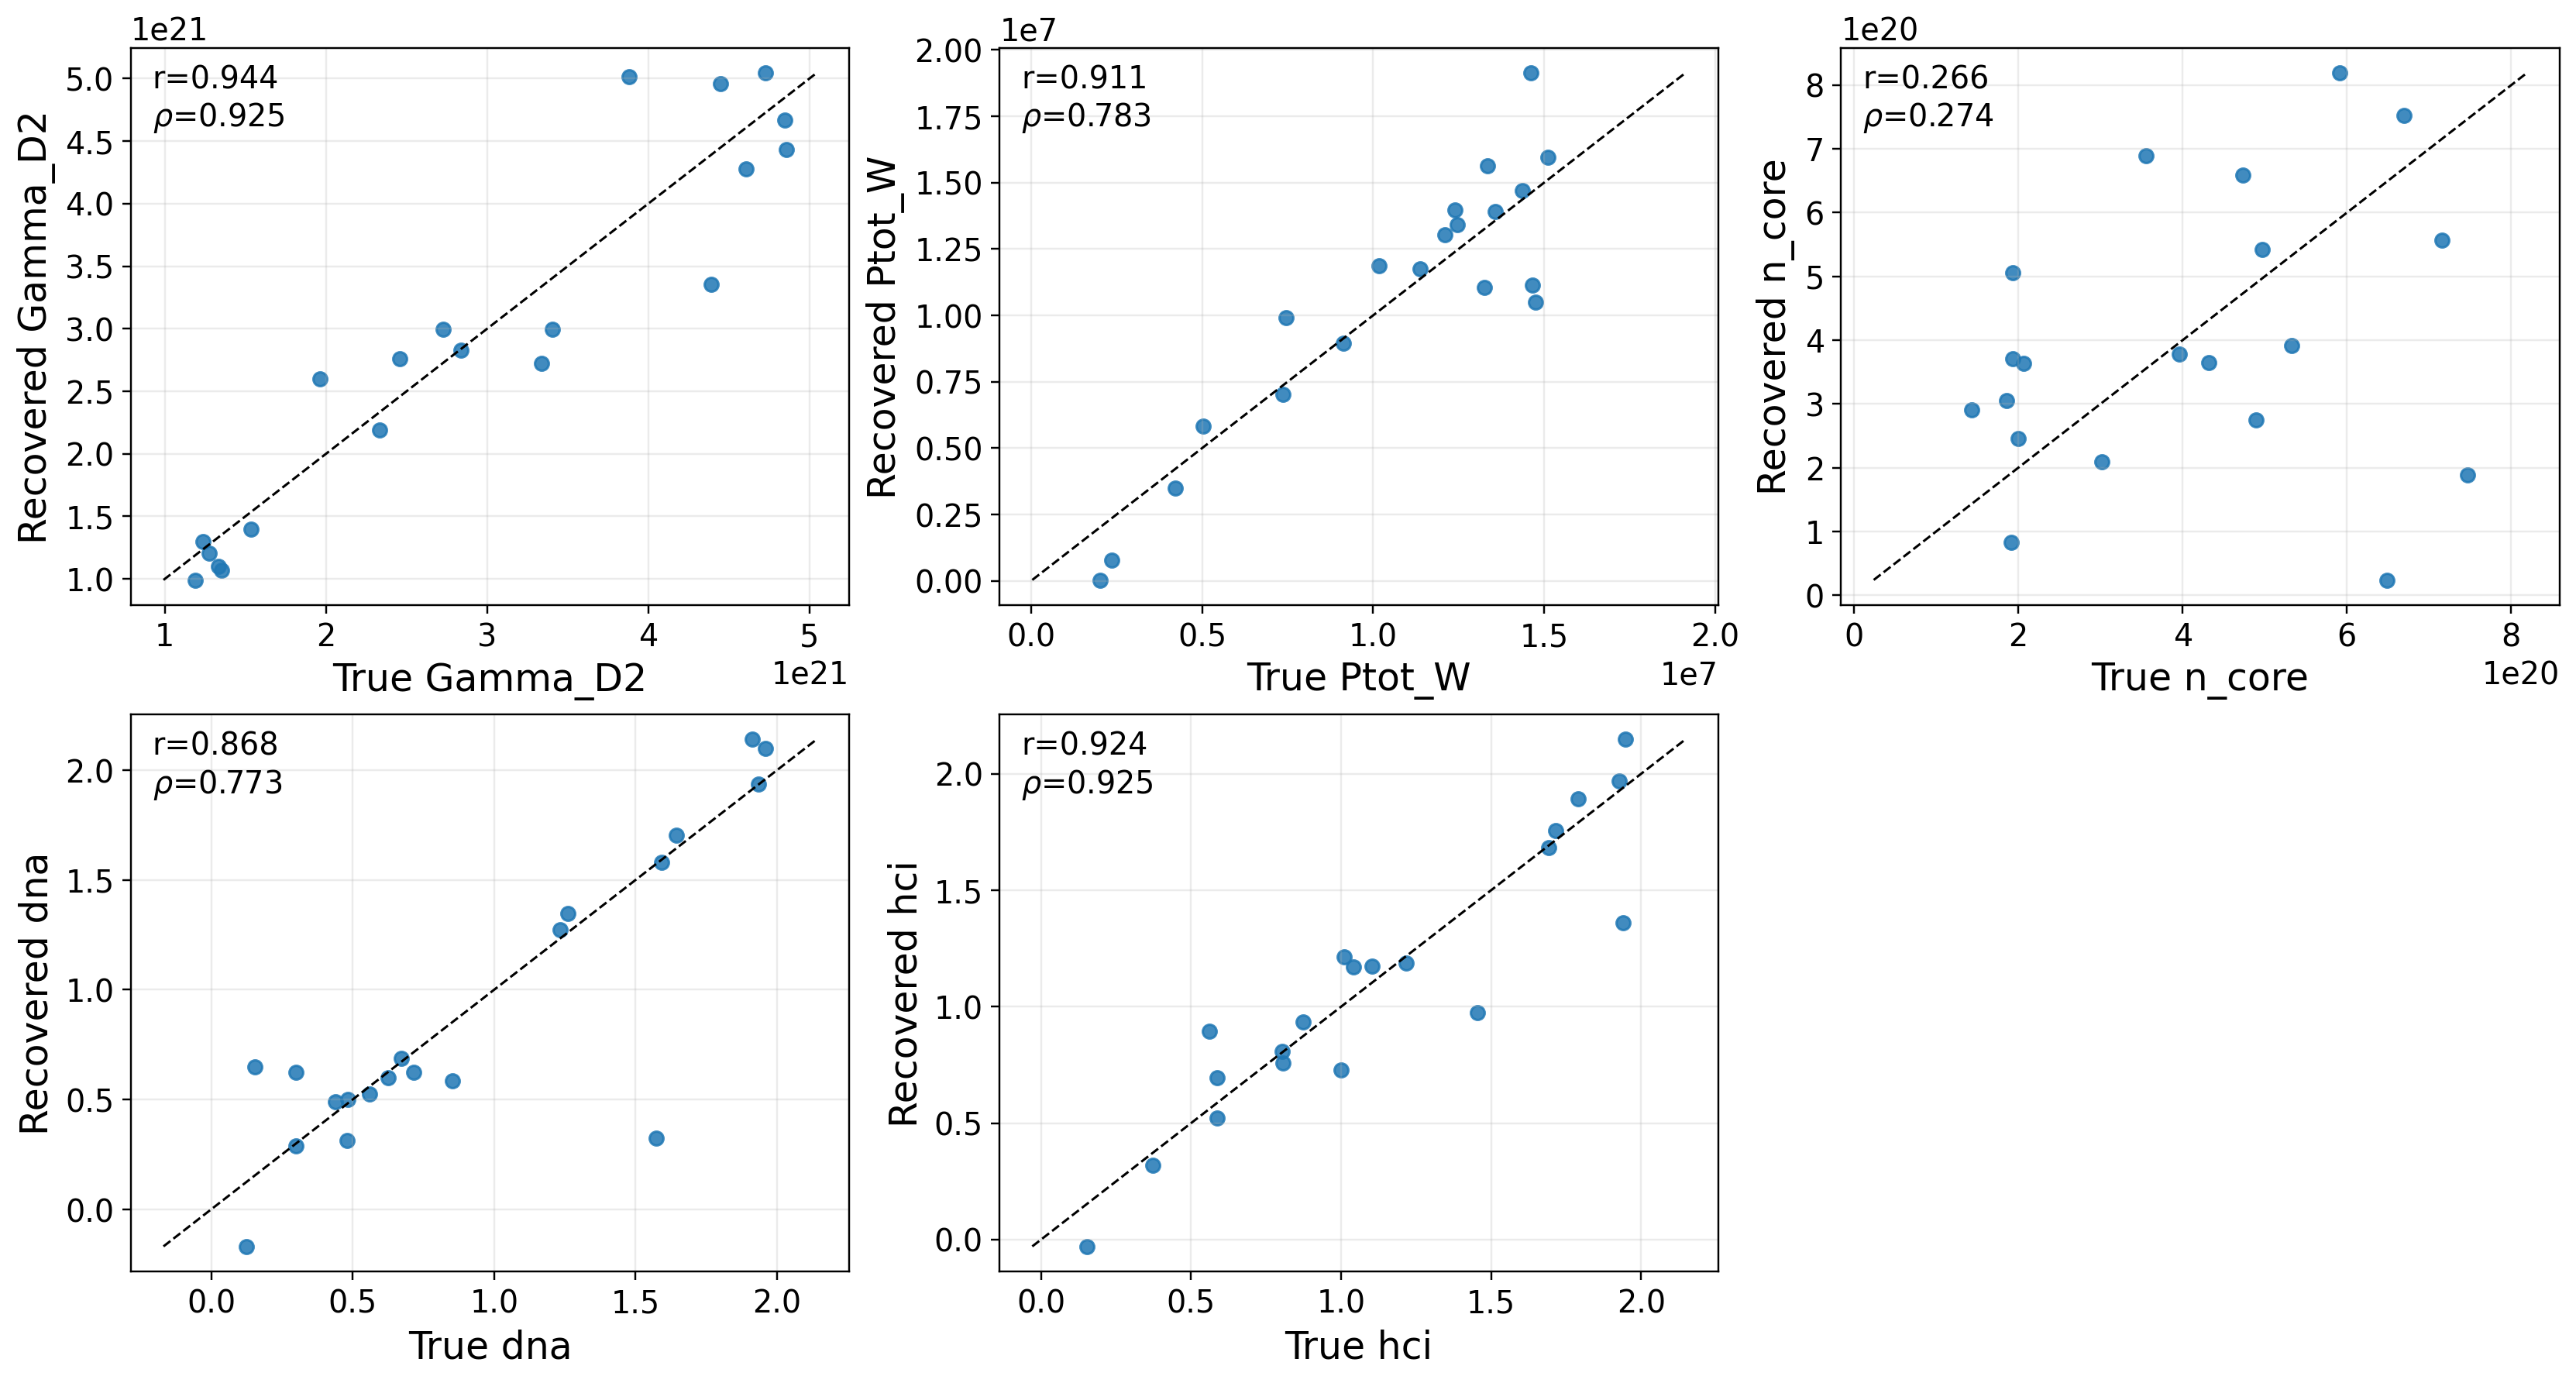

In [ ]:
from IPython.display import Image, display
display(Image(filename="outputs/inverse_param_correlation.png"))

Forward plasma -> sources

In [ ]:
!python eval_source_from_plasma_mesh.py \
    --npz /content/drive/MyDrive/scripts/data/solps.npz \
    --ckpt outputs/cond_unet.pt \
    --base-dir "/content/drive/MyDrive/SOLPS_DB" \
    --all-fields \
    --error-mode abs \
    --error-sign absolute \
    --log-display auto \
    --paper-grid \
    --outdir outputs/source_eval_mesh_abs

Device: cuda
Traceback (most recent call last):
  File "/content/drive/MyDrive/SOLPEx/scripts/eval_source_from_plasma_mesh.py", line 476, in <module>
    main()
  File "/content/drive/MyDrive/SOLPEx/scripts/eval_source_from_plasma_mesh.py", line 329, in main
    raise KeyError("Checkpoint missing x_norm. Retrain with run_source_from_plasma_pipeline.py")
KeyError: 'Checkpoint missing x_norm. Retrain with run_source_from_plasma_pipeline.py'


In [ ]:
!pwd